# A08 Craigslist Auto Scraper Modeling Analysis
### OPIM 5512
### Mark Kulaga
### NetID: mdk23002

In this notebook I'm going to clone my Craigslist scraper repo with the results of my price prediction model, then analyze the metrics produced by the model and examine how the model's performance changes, and hopefully improves, over time as it gains more data.

##1. Cloning the Repository


---



In [59]:
import os, shutil

REPO_URL = "https://github.com/OPIM5512-mdk23002/myscrapers-mdk23002.git"
REPO_DIR = "myscrapers-mdk23002"

#Creating a fresh clone each run so the results are always up to date
if os.path.exists(REPO_DIR):
  shutil.rmtree(REPO_DIR)
!git clone $REPO_URL

RESULTS_DIR = os.path.join(REPO_DIR, "results")
print(f"Results directory: {RESULTS_DIR}")
print(f"Files found: {os.listdir(RESULTS_DIR) if os.path.exists(RESULTS_DIR) else 'None - Check repo'}")

Cloning into 'myscrapers-mdk23002'...
remote: Enumerating objects: 1051, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 1051 (delta 75), reused 56 (delta 2), pack-reused 921 (from 1)
Receiving objects: 100% (1051/1051), 7.72 MiB | 10.59 MiB/s, done.
Resolving deltas: 100% (512/512), done.
Results directory: myscrapers-mdk23002/results
Files found: ['2026040703-pdp_top3.png', '2026040619-metrics.json', '2026040800-pdp_top3.png', '2026040423-pdp_top3.png', '2026040613-preds.csv', '2026040611-metrics.json', '2026040515-preds.csv', '2026040423-permutation_importance.png', '2026040422-pdp_top3.png', '2026040621-metrics.json', '2026040712-permutation_importance.json', '2026040709-permutation_importance.png', '2026040623-metrics.json', '2026040718-metrics.json', '2026040422-permutation_importance.json', '2026040514-permutation_importance.png', '2026040415-pdp_top3.png', '2026040711-preds.csv', '2026040613-permutation_impo

##2. Parsing Synced Artifacts

---

Each run produces artifact files with accuracy metrics, permutation importance, predictions, and the PDPs for the top 3 most important features, all prefixed with the run ID. I'll scan the results folder in my repo and build data frames from the JSON files.

In [60]:
import json
import glob
import pandas as pd
import numpy as np
from datetime import datetime

#Extracting timestamp from runID prefix on files
def parse_run_ts(filename):
  """
  Filenames look like '2026040312-metrics.json'
  The prefix '2026040312' is YYYYMMDDHH.
  Parse it into a proper datetime for plotting.
  """
  prefix = os.path.basename(filename).split("-")[0]
  return datetime.strptime(prefix, "%Y%m%d%H")

#Loading all metrics.json files
metrics_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*-metrics.json")))
print(f"Found {len(metrics_files)} metrics files")

metrics_rows = []
for f in metrics_files:
  with open(f) as fh:
    data = json.load(fh)
  data["run_dt"] = parse_run_ts(f)
  data["run_id"] = os.path.basename(f).split("-")[0]
  metrics_rows.append(data)

df_metrics = pd.DataFrame(metrics_rows).sort_values("run_dt").reset_index(drop=True)
print(f"Metrics runs span: {df_metrics['run_dt'].min()} to {df_metrics['run_dt'].max()}")
df_metrics.head()

Found 67 metrics files
Metrics runs span: 2026-04-04 08:00:00 to 2026-04-08 00:00:00


,run_ts,today_local,train_rows,holdout_rows,mae_today,rmse_today,mape_today,bias_today,best_cv_mae,best_params,run_dt,run_id
0,2026-04-04T08:20:18.646915+00:00,2026-04-04,299,158,5934.019246,11938.289865,97.630550,1133.529159,5348.434600,"{'model__learning_rate': 0.1, 'model__max_dept...",2026-04-04 08:00:00,2026040408
1,2026-04-04T09:51:33.992380+00:00,2026-04-04,256,201,6204.084376,13366.667566,87.670196,615.009916,5886.351648,"{'model__learning_rate': 0.1, 'model__max_dept...",2026-04-04 09:00:00,2026040409
2,2026-04-04T10:20:39.049633+00:00,2026-04-04,256,201,6204.084376,13366.667566,87.670196,615.009916,5886.351648,"{'model__learning_rate': 0.1, 'model__max_dept...",2026-04-04 10:00:00,2026040410
3,2026-04-04T11:20:40.564561+00:00,2026-04-04,237,220,6384.635454,13326.368406,82.423098,-592.498169,6099.594254,"{'model__learning_rate': 0.1, 'model__max_dept...",2026-04-04 11:00:00,2026040411
4,2026-04-04T13:20:36.640796+00:00,2026-04-04,213,244,5942.636090,11775.123801,79.226814,-376.372277,5703.372629,"{'model__learning_rate': 0.1, 'model__max_dept...",2026-04-04 13:00:00,2026040413


In [61]:
#Loading all permutation_importance.json files
imp_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*-permutation_importance.json")))
print(f"Found {len(imp_files)} permutation importance files")

imp_rows = []
for f in imp_files:
  with open(f) as fh:
    records = json.load(fh)
  run_dt = parse_run_ts(f)
  run_id = os.path.basename(f).split("-")[0]
  for rec in records:
    imp_rows.append({
        "run_dt": run_dt,
        "run_id": run_id,
        "feature": rec["feature"],
        "importance": rec["importance_mean"],
    })

df_imp = pd.DataFrame(imp_rows)
print(f"Permutation importance entries: {len(df_imp)} across {df_imp['run_id'].nunique()} runs")

Found 67 permutation importance files
Permutation importance entries: 804 across 67 runs


In [62]:
#Counting PDP images
pdp_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*-pdp_top3.png")))

#Running Summary Table
summary_data = {
    "Metric": [
        "Metrics files found",
        "Permutation importance files found",
        "PDP images found",
        "First run",
        "Latest run",
        "Days spanned",
    ],
    "Value": [
        len(metrics_files),
        len(imp_files),
        len(pdp_files),
        df_metrics["run_dt"].min().strftime("%Y-%m-%d %H:%M") if not df_metrics.empty else "N/A",
        df_metrics["run_dt"].max().strftime("%Y-%m-%d %H:%M") if not df_metrics.empty else "N/A",
        (df_metrics["run_dt"].max() - df_metrics["run_dt"].min()).days if len(df_metrics) > 1 else 0,
    ]
}

display(pd.DataFrame(summary_data))

,Metric,Value
0,Metrics files found,67
1,Permutation importance files found,67
2,PDP images found,66
3,First run,2026-04-04 08:00
4,Latest run,2026-04-08 00:00
5,Days spanned,3


##3. Error Metrics Over Time

---


 This section will track MAE, RMSE, MAPE, and Bias over time to evaluate how well the model is predicting car prices and how it is changing with time.

 My initial expectation is that MAE, RMSE, and MAPE will trend downwards as the model gains more data to work with and Bias will stabilize around zero.

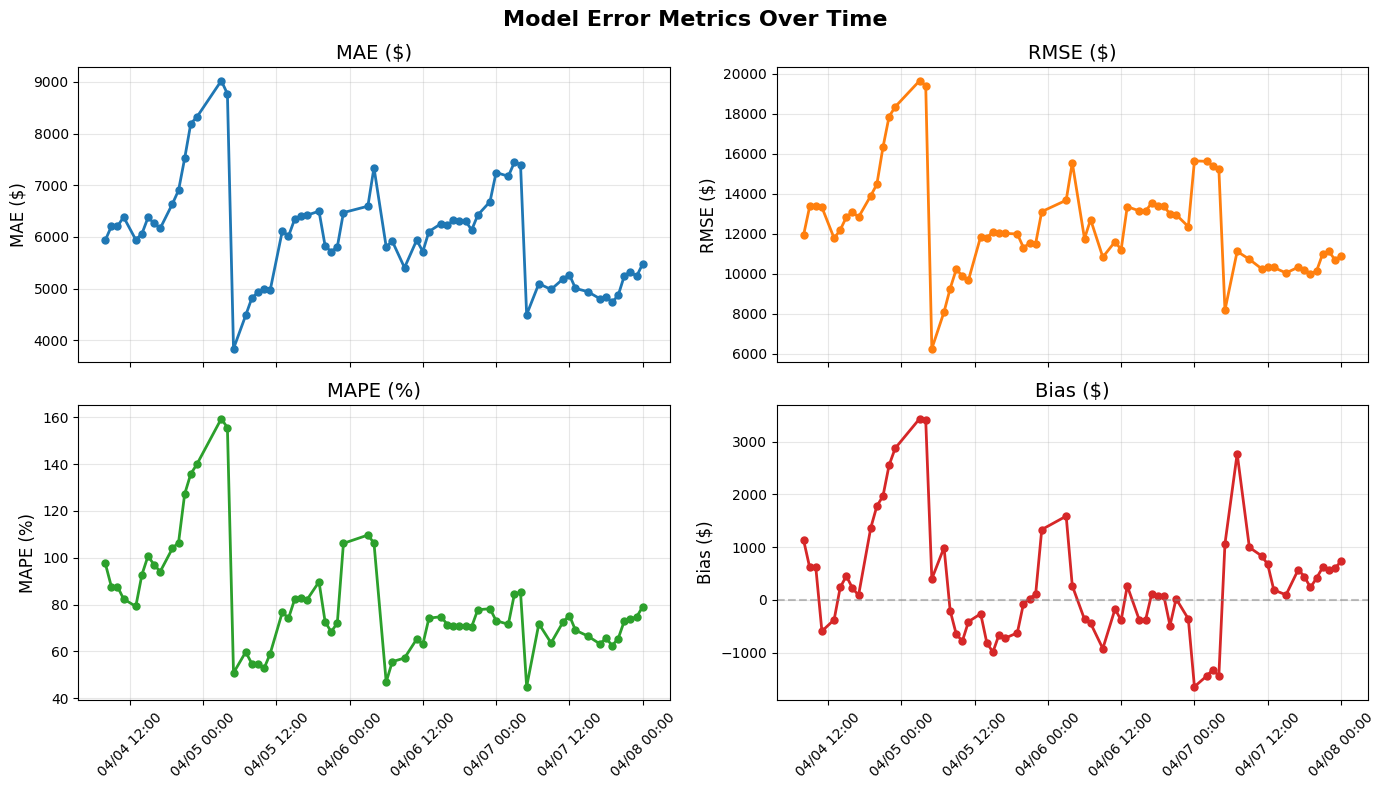

In [63]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle("Model Error Metrics Over Time", fontsize=16, fontweight='bold')

metric_configs = [
    ("mae_today", "MAE ($)", "tab:blue", axes[0, 0]),
    ("rmse_today", "RMSE ($)", "tab:orange", axes[0, 1]),
    ("mape_today", "MAPE (%)", "tab:green", axes[1, 0]),
    ("bias_today", "Bias ($)", "tab:red", axes[1, 1]),
]

for col, label, color, ax in metric_configs:
  if col in df_metrics.columns:
    ax.plot(df_metrics["run_dt"], df_metrics[col],
            marker="o", color=color, linewidth=2, markersize=5)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(label, fontsize=14)
    ax.grid(True, alpha=0.3)

    #Adding a horizontal reference line at 0 for Bias
    if col == "bias_today":
      ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

for ax in axes[1, :]:
  ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:00"))
  ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [64]:
#Numeric summaries of error metric trends
#Splitting runs in half chronologically to compare results from early runs to results from recent runs
if len( df_metrics) >= 2:
  first_half = df_metrics.iloc[:len(df_metrics)//2]
  second_half = df_metrics.iloc[len(df_metrics)//2:]

  trend_summary = pd.DataFrame({
      "Metric": ["MAE ($)", "RMSE ($)", "MAPE (%)", "Bias ($)"],
      "Early Runs (Average)": [
          f"{first_half['mae_today'].mean():,.0f}",
          f"{first_half['rmse_today'].mean():,.0f}",
          f"{first_half['mape_today'].mean():,.1f}",
          f"{first_half['bias_today'].mean():,.0f}",
      ],
      "Recent Runs (Average)": [
          f"{second_half['mae_today'].mean():,.0f}",
          f"{second_half['rmse_today'].mean():,.0f}",
          f"{second_half['mape_today'].mean():,.1f}",
          f"{second_half['bias_today'].mean():,.0f}",
      ],
      "Direction": [
          "Improving" if second_half['mae_today'].mean() < first_half['mae_today'].mean() else "Worsening" if second_half['mae_today'].mean() > first_half['mae_today'].mean() else "Stable",
          "Improving" if second_half['rmse_today'].mean() < first_half['rmse_today'].mean() else "Worsening" if second_half['rmse_today'].mean() > first_half['rmse_today'].mean() else "Stable",
          "Improving" if second_half['mape_today'].mean() < first_half['mape_today'].mean() else "Worsening" if second_half['mape_today'].mean() > first_half['mape_today'].mean() else "Stable",
          "Improving" if abs(second_half['bias_today'].mean()) < abs(first_half['bias_today'].mean()) else "Worsening",
      ],
  })
  print("Error Metric Trends: Early Runs vs. Recent Runs")
  display(trend_summary)
else:
  print("Need at least 2 runs to compare trends")


Error Metric Trends: Early Runs vs. Recent Runs


,Metric,Early Runs (Average),Recent Runs (Average),Direction
0,MAE ($),"6,276","5,813",Improving
1,RMSE ($),"12,758","12,034",Improving
2,MAPE (%),90.8,70.3,Improving
3,Bias ($),546,54,Improving


### Error Metric Interpretation
*  All 4 error metrics are trending in the expected and right direction. MAE improved from an average of 6276 in early runs to 5813 in recent ones, and MAPE dropped from 90.8% to 70.3%. This shows that the model is getting meaningfully better at predicting prices as it accumulates more data.
*   Bias showed the greatest improvement, dropping from an average of 546 in early runs to just 54 in recent runs. This shows the models predictions becoming much more balanced, rather than tending to significantly under or over predict prices.
*   There is a very clear daily pattern visible in all 4 of the trend charts. Errors spike at night, but settle back down in the early morning. This is most likely a result of the ratio of Training to Holdout data shifting throughout the day.
*   MAPE values are still high overall at roughly 70%. This may reflect the model's relative newness as it has been improving with time. I believe it could also be a result of low priced listings producing large error percentages from the model's predictions. Finding a way to address the modeling difficulties introduced by the wide range of prices in the dataset could provide a significant improvement to accuracy.

### Training Set Growth
The model trains on past data, then uses that to predict prices for today's listings. Part of the reason model performance is expected to improve over time is that the dataset will keep growing, giving it more data to learn from.

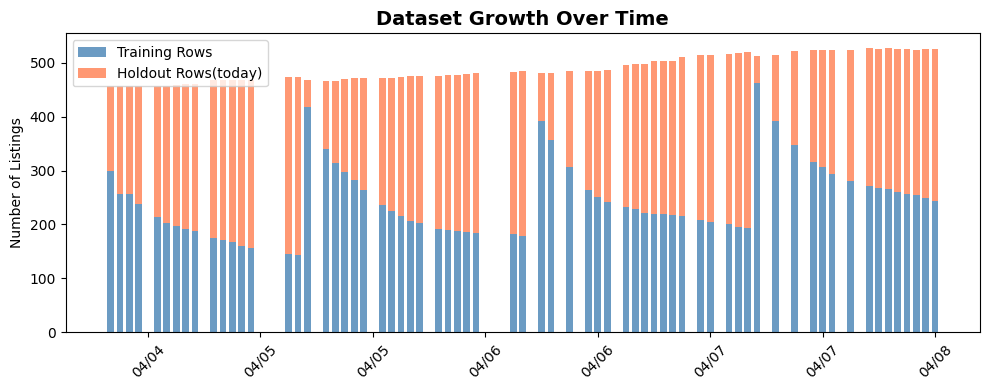

In [65]:
#Tracking ratio of training data to holdout data over time
if "train_rows" in df_metrics.columns:
  fig, ax = plt.subplots(figsize=(10, 4))
  ax.bar(df_metrics["run_dt"], df_metrics["train_rows"],
         width= 0.03, color='steelblue', alpha=0.8, label= "Training Rows")
  if "holdout_rows" in df_metrics.columns:
    ax.bar(df_metrics["run_dt"], df_metrics["holdout_rows"],
           width= 0.03, color='coral', alpha=0.8,
           bottom=df_metrics['train_rows'], label= "Holdout Rows(today)")
  ax.set_ylabel('Number of Listings')
  ax.set_title('Dataset Growth Over Time', fontsize=14, fontweight='bold')
  ax.legend()
  ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
else:
  print("No training/holdout data found. Skipping growth chart.")

### Additional Error Metric Interpretation
The ratio of training rows to holdout rows shows an interesting pattern that I believe is responsible for the daily trends that the error metric graphs above show. The model has only been running for a few days at the time of this analysis, so there is a limited amount of historical data for it to work with. This, combined with the way that the model is set up to  use records from the current day as a holdout set and records from previous days as training, causes the ratio of training to holdout data to shift greatly throughout the day.

Early in the day, when there is much more training data than holdout data, the model performs better than it does later in the day, when there is more holdout data. This pattern is displayed relatively consistently across the 4 error metric graphs. I would expect to see this trend stabilize and eventually disappear as the model gains a greater amount of historical data to work with and the training/holdout ratio stabilizes.

##4. Feature Importance

---

Permutation importance measures the contribution of each feature to predictions. Tracking this over time as the model gains more data to work with can show how the model relies on certain features and whether the specific features that it relies on on most are affected by new data.

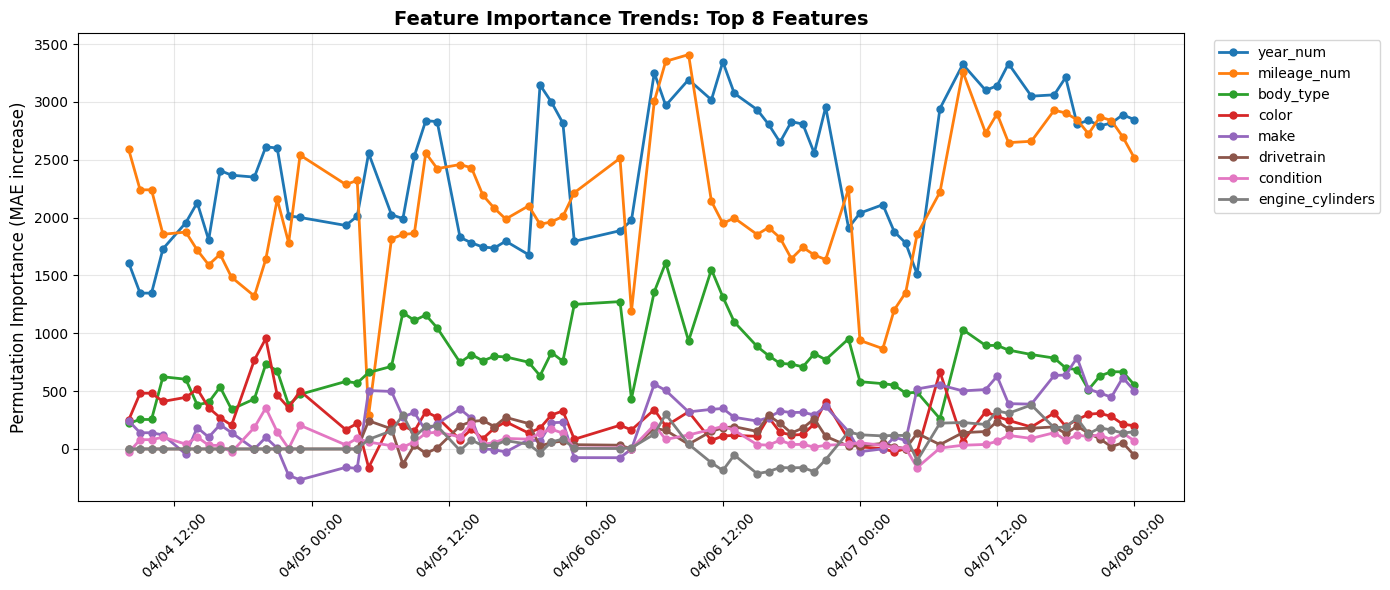

In [66]:
#Tracking permutation importance over time
if not df_imp.empty:
  imp_pivot = df_imp.pivot_table(
      index="run_dt", columns="feature", values="importance",
  ).fillna(0)

  #Charting each feature as a line
  fig, ax = plt.subplots(figsize=(14,6))

  #Sorting features by average importance(most important first)
  avg_imp = imp_pivot.mean().sort_values(ascending=False)
  top_features = avg_imp.head(8).index #showing only the top 8 to keep the chart readable

  for feat in top_features:
    ax.plot(imp_pivot.index, imp_pivot[feat],
            marker="o", linewidth=2,
            markersize=5, label=feat)

  ax.set_ylabel("Permutation Importance (MAE increase)", fontsize=12)
  ax.set_title("Feature Importance Trends: Top 8 Features", fontsize=14, fontweight='bold')
  ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
  ax.grid(True, alpha=0.3)
  ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:00"))
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
else:
  print("No permutation importance data found. Skipping.")

In [67]:
#Tracking feature importance rank stability across runs
if not df_imp.empty and df_imp["run_id"].nunique() >= 2:
  #Ranking features from most to least important for each run
  rank_rows = []
  for run_id, group in df_imp.groupby("run_id"):
    ranked = group.sort_values("importance", ascending=False).reset_index(drop=True)
    for rank, row in ranked.iterrows():
      rank_rows.append({
          "run_id": run_id,
          "feature": row["feature"],
          "rank": rank + 1
      })
  df_ranks = pd.DataFrame(rank_rows)

  #Average rank and standard deviation for each feature
  rank_summary = df_ranks.groupby("feature")["rank"].agg(["mean", "std"]).sort_values("mean")
  rank_summary.columns = ["Average Rank", "Rank Std Dev"]
  rank_summary["Average Rank"] = rank_summary["Average Rank"].round(1)
  rank_summary["Rank Std Dev"] = rank_summary["Rank Std Dev"].round(2)
  rank_summary["Stability"] = rank_summary["Rank Std Dev"].apply(
      lambda x: "Stable" if x < 1.0 else "Moderate" if x < 2.0 else "Volatile")

  print("Feature Importance Rank Summary and Stability Across Runs")
  display(rank_summary)

Feature Importance Rank Summary and Stability Across Runs


,Average Rank,Rank Std Dev,Stability
feature,,,
year_num,1.3,0.47,Stable
mileage_num,1.7,0.55,Stable
body_type,3.2,0.49,Stable
color,5.2,1.83,Moderate
make,5.9,3.03,Volatile
condition,7.1,1.76,Moderate
drivetrain,7.1,2.03,Volatile
model,8.2,1.66,Moderate
engine_cylinders,8.4,3.00,Volatile


## Interpretation of Feature Importance Trends
* Year and Mileage are consistently the most important features by a wide margin. This makes intuitive sense, too. When shopping for a car, these are some of the things that I fell have the most impact on how much I'm willing to pay.

* Body type takes a relatively stable 3rd place for importance. I was glad to see this because it is one of my LLM extracted fields, which shows that the schema extension added real value to the pipeline. This ranking also makes intuitive sense to me. People are usually willing to pay more for certain types of cars such as convertibles or trucks.

* Make and Engine Cylinders were the most volatile features, with standard deviations of 3.03 and 3.00 respectively. This means that their importance changed a lot between runs. I think part of this could be due to the changing mix of car brands in the dataset as it expands.

* The remaining LLM fields that I added, color, drivetrain, condition, fuel type, and title status, all ranked relatively low in feature importance, but none of them consistently stayed at 0, so including them in the model is still valuable.


#5. Partial Dependence Plots Over Time

---



Found 66 PDP images

Earliest Top 3 PDP - 2026-04-04 09:00


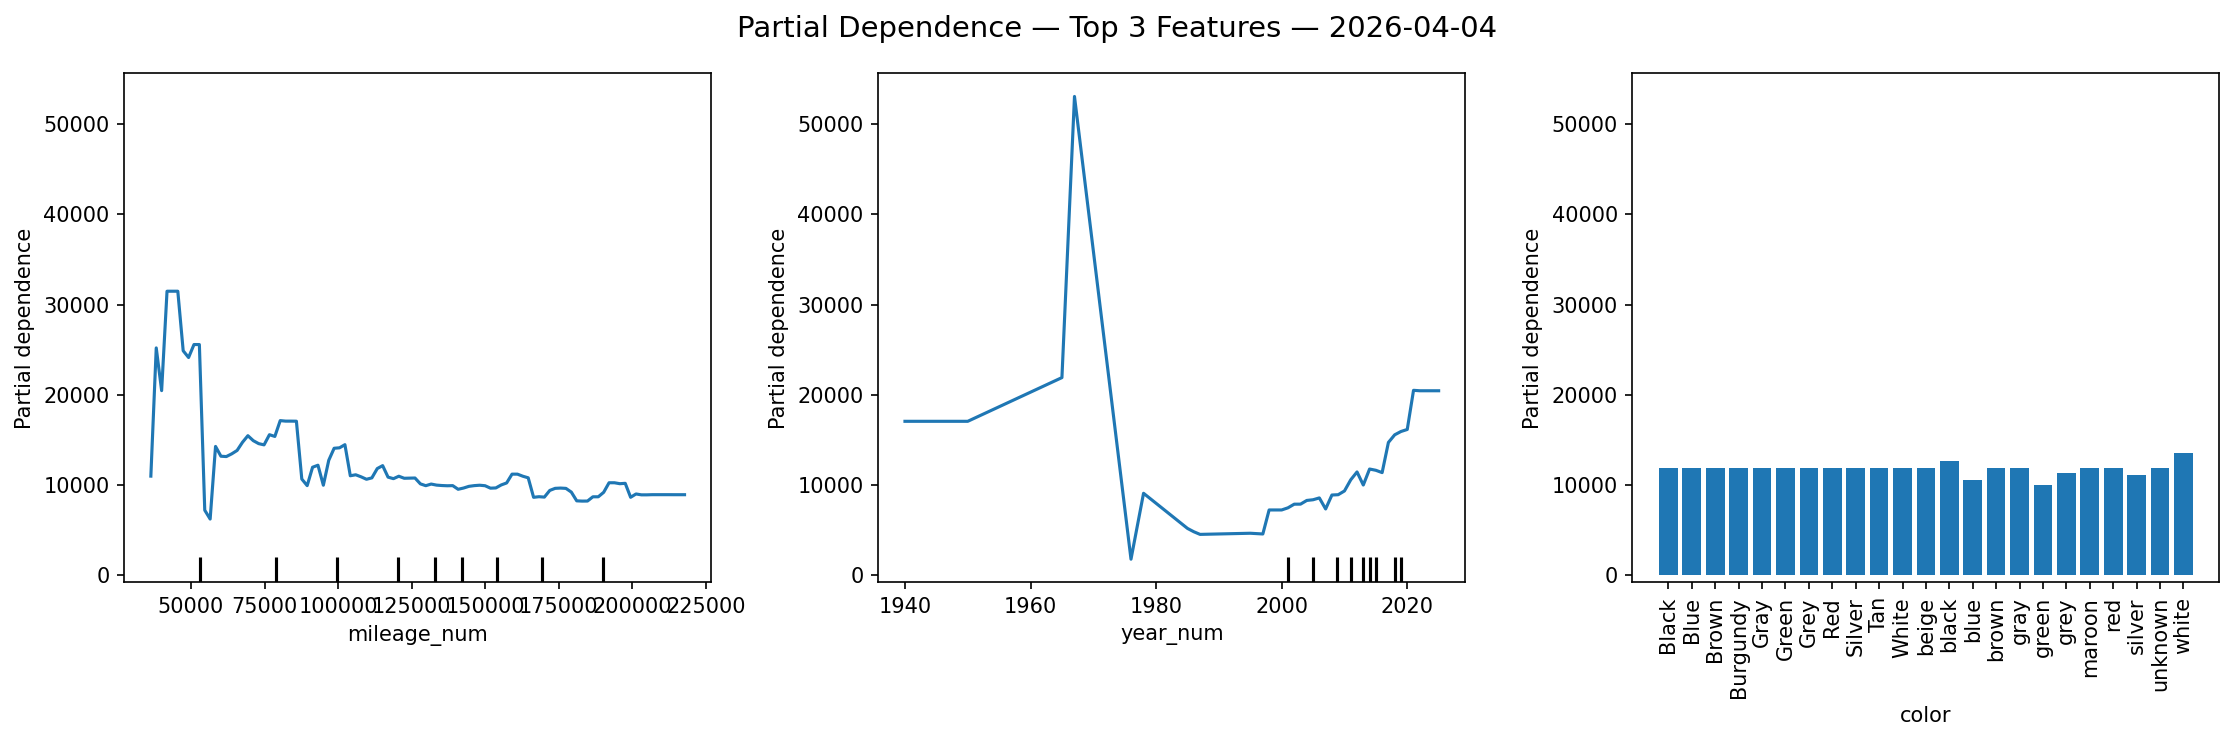


Latest Top 3 PDP - 2026-04-08 00:00


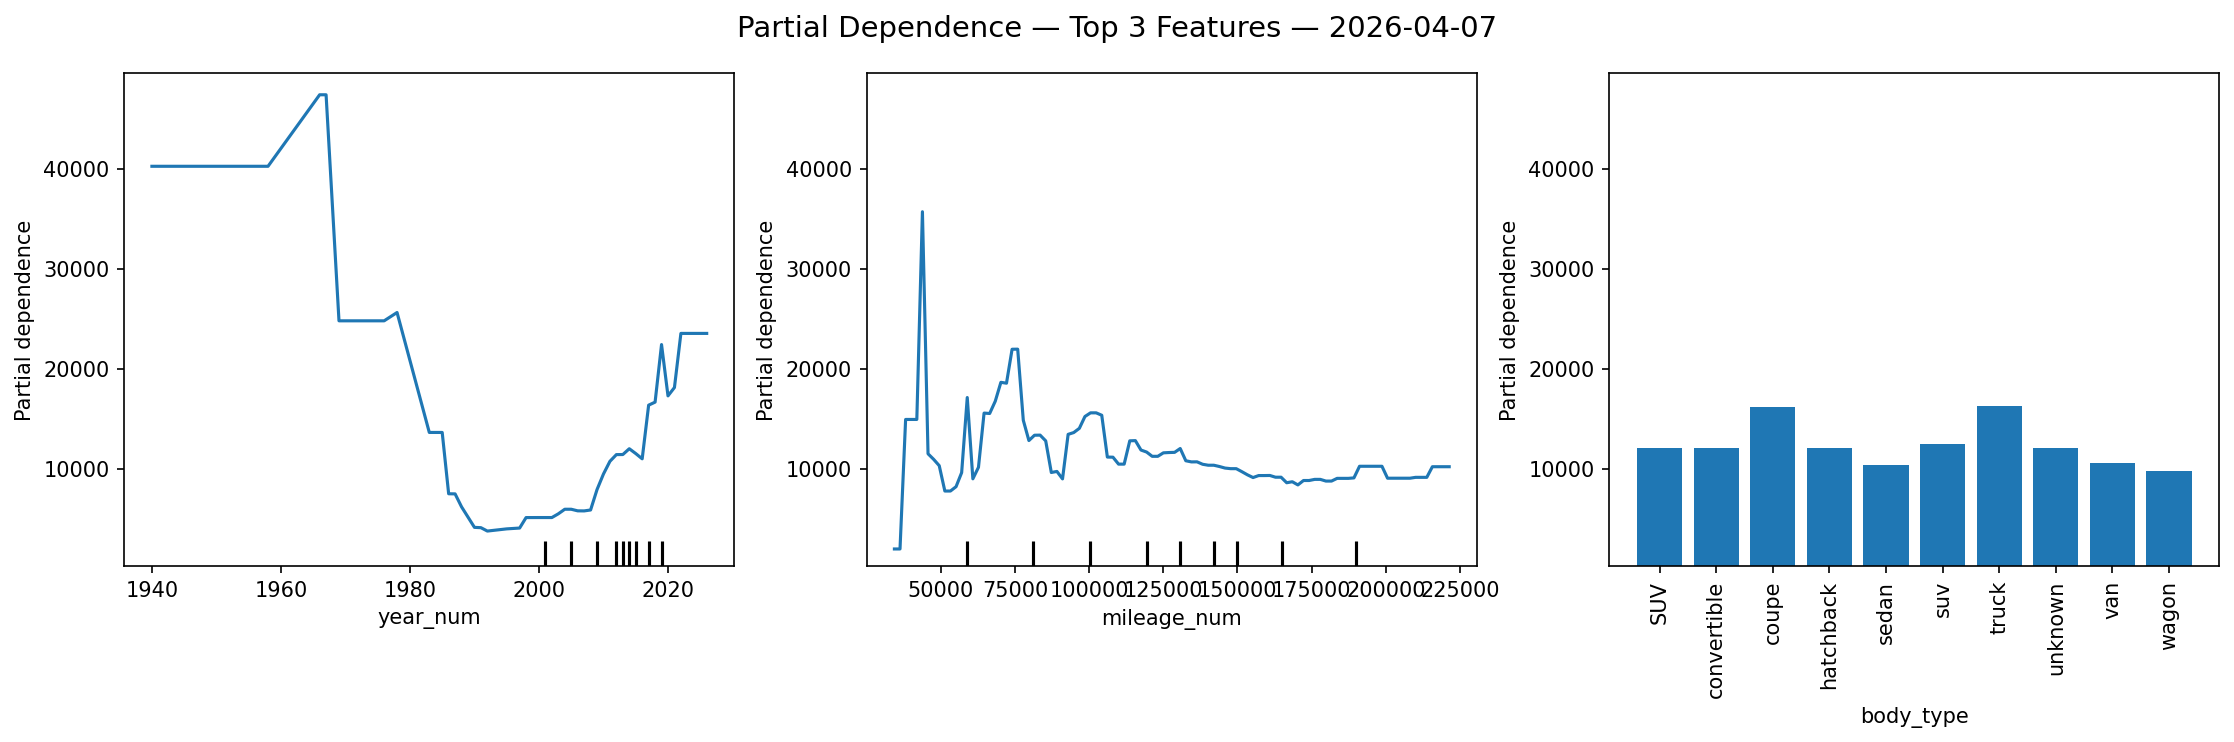

In [68]:
#Comparing PDPs for top 3 features from earliest run and latest run
from IPython.display import display, Image as IPImage

print(f"Found {len(pdp_files)} PDP images\n")

if len(pdp_files) >= 2:
  earliest = pdp_files[0]
  latest = pdp_files[-1]

  earliest_dt = parse_run_ts(earliest).strftime("%Y-%m-%d %H:00")
  latest_dt = parse_run_ts(latest).strftime("%Y-%m-%d %H:00")

  print(f"Earliest Top 3 PDP - {earliest_dt}")
  display(IPImage(filename=earliest, width=800))
  print()
  print(f"Latest Top 3 PDP - {latest_dt}")
  display(IPImage(filename=latest, width=800))

elif len(pdp_files) == 1:
  run_dt = parse_run_ts(pdp_files[0]).strftime("%Y-%m-%d %H:00")
  print(f"Only one run's PDP available - {run_dt}")
  display(IPImage(filename=pdp_files[0], width=800))

else:
  print("No PDP images found. Skipping.")

##PDP Trend Analysis
* The top 3 features shift slightly across runs. In the earliest run, mileage, year, and color were most important, while in the latest run,it was year, mileage, and body type. This line up with what the rank stability table I made showed, where color was volatile and body type was relatively stable in 3rd place for importance.

* In both the earliest and the latest runs, the PDP for Year shows a spike in value around the 1960's and 1970's. I suspect this is a result of premium prices for classic muscle cars from that era. Aside from that peak, price seems to drop through the 1990's and 2000's before rising back up for newer vehicles.

* The Mileage PDP shows a consistent pattern accross runs, with price falling as mileage rises. This makes intuitive sense with the used car market, and it's exactly what I would expect to see.

* Body type replaced color as a top 3 feature in more recent runs. The pattern shown in it is just as intuitive as those shown in the other PDPs, with trucks and coupes bringing in a slight price premium over other types. This supports what I've observed in the used car market myself. I've seen that trucks retain value well, likely because of durability and practicality, and the coupe body type is common with sports cars, which would naturally have higher prices.

#6. Hyperparameter Tracking

---



In [69]:
#Displaying best parameters per run
if "best_params" in df_metrics.columns:
  params_display = df_metrics[["run_dt", "train_rows", "best_cv_mae", "best_params"]].copy()
  params_display["run_dt"] = params_display["run_dt"].dt.strftime("%m-%d %H:00")

  #Expanding best_params dict into columns for readability
  params_expanded = pd.json_normalize(params_display["best_params"])
  #removing "model" prefix from column names
  params_expanded.columns = [c.replace("model__", "") for c in params_expanded.columns]

  result = pd.concat([
      params_display[["run_dt", "train_rows", "best_cv_mae"]].reset_index(drop=True),
      params_expanded
  ], axis=1)

  print("Best Hyperparameters Selected by GridSearchCV in Each Run")
  display(result)
else:
  print("No best parameters found. Skipping")

Best Hyperparameters Selected by GridSearchCV in Each Run


,run_dt,train_rows,best_cv_mae,learning_rate,max_depth,min_samples_leaf,n_estimators
0,04-04 08:00,299,5348.434600,0.10,7,5,300
1,04-04 09:00,256,5886.351648,0.10,7,5,300
2,04-04 10:00,256,5886.351648,0.10,7,5,300
3,04-04 11:00,237,6099.594254,0.10,7,5,300
4,04-04 13:00,213,5703.372629,0.10,5,5,300
...,...,...,...,...,...,...,...
62,04-07 20:00,261,6372.904102,0.05,7,5,300
63,04-07 21:00,256,6075.207004,0.10,5,5,300
64,04-07 22:00,254,6216.938854,0.10,5,5,300
65,04-07 23:00,249,6165.265263,0.10,5,5,300


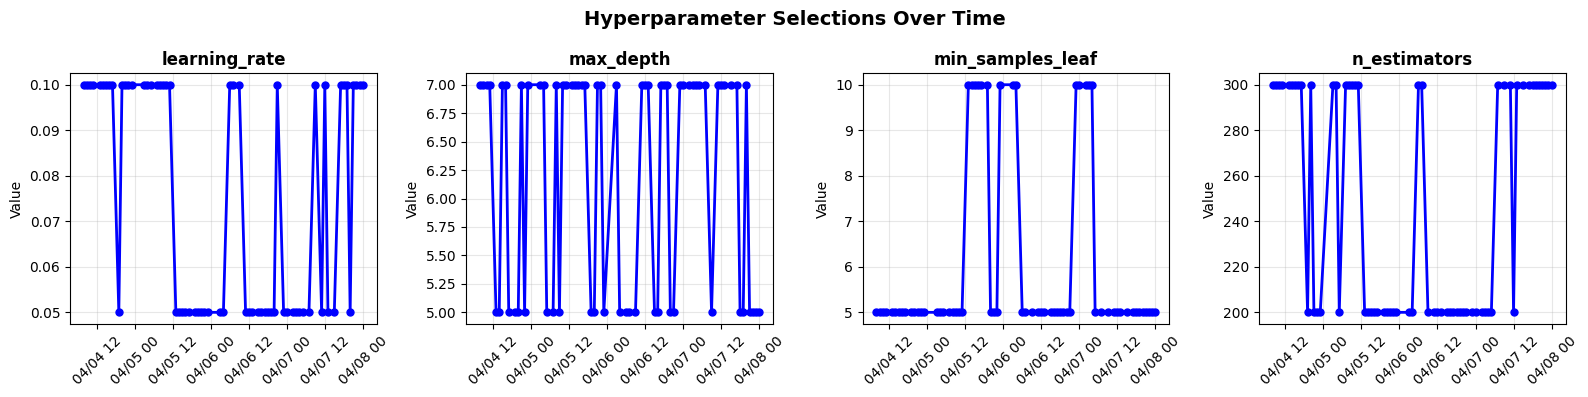

In [70]:
#Visualizing Hyperparameter choices over time
if "best_params" in df_metrics.columns and len(df_metrics) >= 2:
  params_expanded_ts = pd.json_normalize(df_metrics["best_params"])
  params_expanded_ts.columns = [c.replace("model__", "") for c in params_expanded_ts.columns]
  params_expanded_ts["run_dt"] = df_metrics["run_dt"].values

  param_names = [c for c in params_expanded_ts.columns if c != "run_dt"]
  n_params = len(param_names)

  fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))
  if n_params == 1:
    axes = [axes]

  for ax, param in zip(axes, param_names):
    ax.plot(params_expanded_ts["run_dt"], params_expanded_ts[param],
            marker="o", linewidth=2, markersize=5, color="blue")
    ax.set_title(param, fontsize=12, fontweight="bold")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H"))
    ax.tick_params(axis="x", rotation=45)

  fig.suptitle("Hyperparameter Selections Over Time", fontsize=14, fontweight="bold")
  plt.tight_layout()
  plt.show()


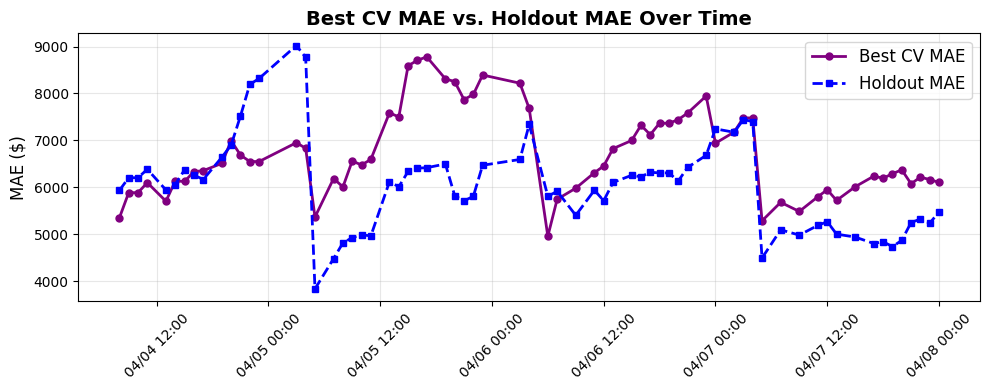

In [71]:
#Cross-Validation MAE vs. Holdout MAE
if "best_cv_mae" in df_metrics.columns:
  fig, ax = plt.subplots(figsize=(10,4))
  ax.plot(df_metrics["run_dt"], df_metrics["best_cv_mae"],
          marker="o", linewidth=2, markersize=5, color="purple", label="Best CV MAE")
  if "mae_today" in df_metrics.columns:
    ax.plot(df_metrics["run_dt"], df_metrics["mae_today"],
            marker="s", linewidth=2, markersize=5, color="blue",
            linestyle='--', label="Holdout MAE")
    ax.set_ylabel("MAE ($)", fontsize=12)
    ax.set_title("Best CV MAE vs. Holdout MAE Over Time", fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:00"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##Hyperparameter Tracking Analysis
* GridSearchCV seems to slightly favor the same configuration: learning rate = 0.10, max_depth = 7, min_samples_leaf = 5, n_estimators = 300. This specific combination suggests that the model favors complexity and capacity as each parameter is set to it's largest or most aggressive value.

* The model seems to bounce between the extreme values of the GridSearch I set up when it does change. This suggests to me that it would benefit from wider limits to evaluate in the future. In this case, I made a conscious choice to limit the range of the search, because I was concerned that a larger grid would take too long for the model to work with and potentially lead to timeout issues.

* The CV MAE vs. Holdout MAE chart shows the two lines staying relatively close for most of the time covered. This suggests that the CV score is a reasonably reliable estimate of real-world performance and the model is not badly overfitting.

# 7. Analysis Conclusion

---
The pipeline has currently been running hourly for about 4 days. All four error metrics have shown improvements over that time as the training dataset has grown. Feature importance and Partial Dependence Plots show the Year and Mileage are the strongest predictors in the dataset, which intuitively makes sense in this scenario with used cars. The LLM extracted fields I added to the pipeline, especially body type and color, do seem to be contributing meaningfully beyond the pipeline's core listing data.

The main limitation the model has right now is dataset size. All metrics are still improving, and with more time I would expect them to eventually stabilize. This would flatten out the daily trends that this analysis shows so strongly right now and potentially stabilize the more volatile features in the data, like make and engine cylinders.

Location fields were extracted and added to the ETL, but I chose to exclude them from the model because of their low fill rates. With more time, this problem would correct itself as the pipeline gathered more data, and I would expect to see interesting patterns relating pricing and location.